# Sim Combinations - fitting multiple power spectra to a spectral model

- For a given exponent, if you simulate M versions, and fit them all, what is the distribution of fit values (aka how variable is it). How does this relate to different simulation & fitting parameters?

### Imports

In [19]:
# Import required functionality

import numpy as np #Imports numpy and then shortens its name

from neurodsp.utils import create_times # this allows us to create a time axis for our signal
from neurodsp.sim import sim_powerlaw, sim_oscillation, sim_combined, set_random_seed # these allow us to simulate a time series
from neurodsp.spectral import compute_spectrum_welch # this allows us to compute power spectra
from neurodsp.plts import plot_time_series, plot_power_spectra # these allow us to plot time series and spectra

from specparam.plts import plot_spectra # Plot one or multiple power spectra
from specparam import SpectralGroupModel #This allows us to initialise and fit multiple signals to a spectral model
from specparam.sim import sim_group_power_spectra
from specparam.sim.params import param_sampler

from matplotlib import pyplot

### Data Simulation Settings

In [11]:
# First need to create a seed and simulation settings so that there is consistency in the simulated data
set_random_seed(21)

# Simulation settings
n_seconds = 5 # Number of seconds
s_rate = 500 # Sampling rate

# Compute an array of time values for plotting, and check length of data
times = create_times(n_seconds, s_rate)

### Simulate multiple pink noise signals and power spectra

In [16]:
#Simulates 25 pink noise signals and computes their power spectra
n_signals = 25
all_spectra_p = []

#Simulate signal, calc power spectrum and store spectrum
for _ in range(n_signals):
    pink_signal = sim_powerlaw(n_seconds, s_rate, exponent=-1)
    freqs_p, powers = compute_spectrum_welch(pink_signal, s_rate)
    all_spectra_p.append(powers)

# Convert to 2D array
all_spectra_p = np.array(all_spectra_p)

### Fit, print and plot Spectral Model for pink noise

C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\data\data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)



	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Fitting model across 25 power spectra.
                                                                                                  
                            GROUP SPECTRAL MODEL RESULTS (25 spectra)                             
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 1-250 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
          

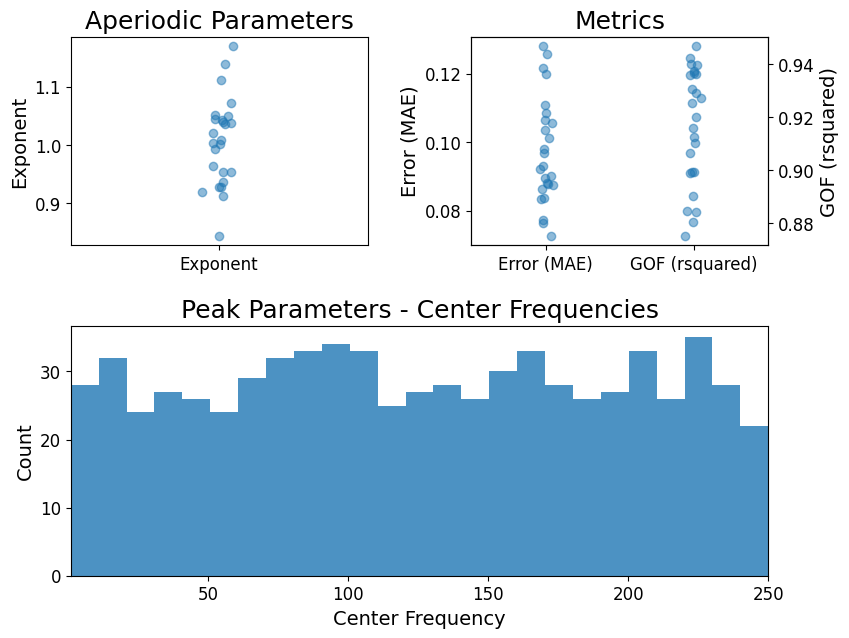

In [15]:
# Fit model
fg = SpectralGroupModel()
fg.fit(freqs_p, all_spectra_p)

# Print model results
fg.print_results()

# Plot a summary of the results across the group
fg.plot()

### Simulate multiple brown noise signals and power spectra

- Here, the sim_group_power_spectra() function is used instead

In [17]:
# Simulate multiple power spectra
freqs_b, all_spectra_b = sim_group_power_spectra(30, [1, 50], {'fixed' : [1, -2]}, {'gaussian' : [10, 0.5, 1]}) 

### Fit, print and plot Spectral Model for brown noise


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Fitting model across 30 power spectra.
                                                                                                  
                            GROUP SPECTRAL MODEL RESULTS (30 spectra)                             
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 1-50 Hz frequency range with 0.50 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
          

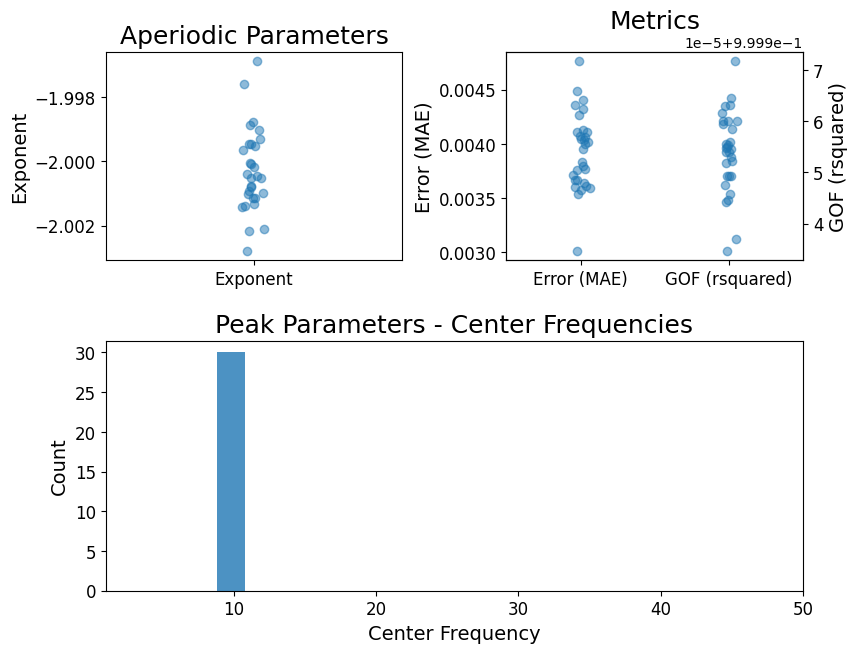

In [18]:
# Fit model
fg = SpectralGroupModel()
fg.fit(freqs_b, all_spectra_b)

# Print model results
fg.print_results()

# Plot a summary of the results across the group
fg.plot()

### Simulating multiple signals with random parameters 

In [21]:
ap_opts = param_sampler([[0, 1.0], [0, 1.5], [0, 2]])
pe_opts = param_sampler([[], [10, 0.5, 1], [10, 0.5, 1, 20, 0.25, 1]])
freqs_r, powers_r = sim_group_power_spectra(10, [1, 50],
                                        {'fixed' : ap_opts}, {'gaussian' : pe_opts})

### Fit, print and plot Spectral Model for multiple signals


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Fitting model across 10 power spectra.
                                                                                                  
                            GROUP SPECTRAL MODEL RESULTS (10 spectra)                             
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 1-50 Hz frequency range with 0.50 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
          

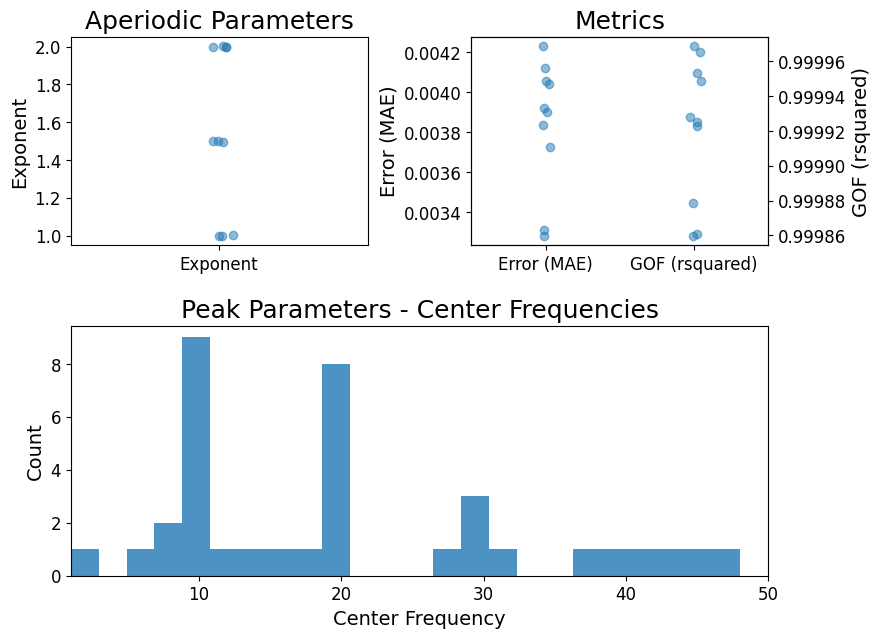

In [22]:
# Fit model
fg = SpectralGroupModel()
fg.fit(freqs_r, powers_r)

# Print model results
fg.print_results()

# Plot a summary of the results across the group
fg.plot()